
# Modelling.ipynb — KKBox Churn (baseline from original Processing pipeline)

Mục tiêu của notebook:

1. Nạp dữ liệu đã xử lý từ `Processing.ipynb`
2. Chạy sanity check trước modelling
3. Train các baseline:
   - Logistic Regression
   - LightGBM
   - XGBoost
4. Đánh giá bằng:
   - ROC-AUC
   - PR-AUC
   - Log Loss
   - Precision / Recall / F1
5. Tune threshold theo business
6. Xuất prediction, importance, model artifact

> Lưu ý: notebook này **giữ nguyên output của Processing.ipynb trước**, chưa ép sang time-based validation mới. Mục tiêu là có baseline đầu tiên để so sánh.


In [1]:

# ===== 1. Imports =====
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
from xgboost import XGBClassifier

import matplotlib.pyplot as plt


In [2]:

# ===== 2. Paths =====
DATA_DIR = Path("Data")
ARTIFACT_DIR = Path("Artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True, parents=True)

TRAIN_X_PATH = DATA_DIR / "X_train.parquet"
VAL_X_PATH   = DATA_DIR / "X_val.parquet"
TRAIN_Y_PATH = DATA_DIR / "y_train.parquet"
VAL_Y_PATH   = DATA_DIR / "y_val.parquet"

for p in [TRAIN_X_PATH, VAL_X_PATH, TRAIN_Y_PATH, VAL_Y_PATH]:
    print(f"{p}: {'FOUND' if p.exists() else 'MISSING'}")


Data\X_train.parquet: FOUND
Data\X_val.parquet: FOUND
Data\y_train.parquet: FOUND
Data\y_val.parquet: FOUND


In [3]:

# ===== 3. Load data =====
if not all(p.exists() for p in [TRAIN_X_PATH, VAL_X_PATH, TRAIN_Y_PATH, VAL_Y_PATH]):
    raise FileNotFoundError(
        "Không tìm thấy parquet output từ Processing.ipynb. "
        "Hãy chạy Processing.ipynb trước hoặc sửa lại đường dẫn Data/."
    )

X_train = pd.read_parquet(TRAIN_X_PATH)
X_val   = pd.read_parquet(VAL_X_PATH)
y_train = pd.read_parquet(TRAIN_Y_PATH).iloc[:, 0]
y_val   = pd.read_parquet(VAL_Y_PATH).iloc[:, 0]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

display(X_train.head())


X_train: (776768, 32)
X_val  : (194192, 32)
y_train: (776768,)
y_val  : (194192,)


,city,bd,gender,registered_via,n_txns,cancel_rate,auto_renew_rate,avg_plan_days,share_30d,zero_paid_rate,...,txn_recency_ratio,activity_freshness,arpu,engagement_score,passive_user,churn_risk_score,inactive_ratio,subscription_stability,cancel_pressure,activity_decay
476786,5,26.0,male,3,1.0,0.0,0.0,30.0,1.0,0.0,...,0.142857,NaN,0.098847,NaN,0,NaN,0.548600,0.0,0.0,NaN
689930,1,28.0,Unknown,7,1.0,0.0,1.0,30.0,1.0,0.0,...,0.052632,NaN,0.130473,NaN,0,NaN,0.874781,1.0,0.0,NaN
332397,1,28.0,Unknown,7,1.0,0.0,1.0,30.0,1.0,0.0,...,0.035714,0.002865,0.213467,2641.5,0,9.333333,0.001433,1.0,0.0,1.0
158772,12,25.0,female,3,2.0,0.0,1.0,30.0,1.0,0.0,...,1.000000,NaN,0.188727,NaN,0,NaN,0.632679,1.0,0.0,NaN
39054,1,28.0,Unknown,7,1.0,1.0,1.0,30.0,1.0,0.0,...,0.055556,NaN,0.051349,NaN,0,NaN,0.518154,0.0,17.0,NaN


In [4]:

# ===== 4. Sanity check =====
print("Target distribution:")
print("Train churn rate:", y_train.mean())
print("Val churn rate  :", y_val.mean())
print()

print("Missing values in X_train:")
display(X_train.isna().sum().sort_values(ascending=False).head(20))

print("Dtypes:")
display(X_train.dtypes.value_counts())


Target distribution:
Train churn rate: 0.08994191315811156
Val churn rate  : 0.08994191315811156

Missing values in X_train:


churn_risk_score            595887
activity_freshness          591019
activity_decay              591017
engagement_score            591017
arpu                        116532
inactive_ratio               88058
txn_recency_ratio            29916
subscription_stability       29916
cancel_pressure              29916
city                             0
gender                           0
bd                               0
n_txns                           0
cancel_rate                      0
auto_renew_rate                  0
registered_via                   0
total_secs_mean                  0
max_unique_songs_per_day         0
active_days                      0
last_gap_days                    0
dtype: int64

Dtypes:


float64     28
category     1
category     1
category     1
int64        1
Name: count, dtype: int64

In [5]:

# ===== 5. Detect feature types =====
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns    :", len(numeric_cols))
print("\nSample categorical columns:", categorical_cols[:15])
print("\nSample numeric columns:", numeric_cols[:15])


Number of categorical columns: 3
Number of numeric columns    : 29

Sample categorical columns: ['city', 'gender', 'registered_via']

Sample numeric columns: ['bd', 'n_txns', 'cancel_rate', 'auto_renew_rate', 'avg_plan_days', 'share_30d', 'zero_paid_rate', 'total_amount_paid', 'avg_discount_rate', 'last_gap_days', 'active_days', 'max_unique_songs_per_day', 'total_secs_mean', 'completion_ratio', 'early_skip_rate']



## 6. Helper functions


In [6]:

def evaluate_predictions(y_true, y_proba, threshold=0.5, model_name="model"):
    y_pred = (y_proba >= threshold).astype(int)
    metrics = {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    return metrics


def threshold_search(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rows.append({
            "threshold": th,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "tn": tn, "fp": fp, "fn": fn, "tp": tp
        })
    return pd.DataFrame(rows)


def business_threshold_search(y_true, y_proba, value_saved=100, intervention_cost=10, thresholds=None):
    """
    value_saved: giá trị giữ lại được nếu cứu đúng 1 khách churn
    intervention_cost: chi phí can thiệp cho 1 khách được nhắm mục tiêu
    profit = TP * value_saved - (TP + FP) * intervention_cost
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        profit = tp * value_saved - (tp + fp) * intervention_cost
        rows.append({
            "threshold": th,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "profit": profit,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)



## 7. Baseline 1 — Logistic Regression

Dùng làm benchmark dễ giải thích.  
Với categorical features, dùng One-Hot Encoding.


In [7]:

# ===== 7. Logistic Regression pipeline =====
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

print("Training Logistic Regression...")
logit_model.fit(X_train, y_train)

logit_val_proba = logit_model.predict_proba(X_val)[:, 1]
logit_metrics = evaluate_predictions(y_val, logit_val_proba, threshold=0.5, model_name="LogisticRegression")
pd.DataFrame([logit_metrics])


Training Logistic Regression...


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,LogisticRegression,0.5,0.965954,0.781681,0.250291,0.608013,0.871465,0.716282



## 8. Baseline 2 — LightGBM

Giữ đúng tinh thần top baseline của cuộc thi: boosting trên dữ liệu bảng là mũi nhọn.  
Ở đây dùng mã hóa category thành integer codes để LightGBM xử lý ổn định.


In [8]:

# ===== 8. Prepare data for tree models =====
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()

for col in categorical_cols:
    all_vals = pd.concat([X_train_tree[col], X_val_tree[col]], axis=0).astype("category")
    categories = all_vals.cat.categories
    X_train_tree[col] = pd.Categorical(X_train_tree[col], categories=categories).codes
    X_val_tree[col] = pd.Categorical(X_val_tree[col], categories=categories).codes

# fill numeric missing if any
for col in numeric_cols:
    med = X_train_tree[col].median()
    X_train_tree[col] = X_train_tree[col].fillna(med)
    X_val_tree[col] = X_val_tree[col].fillna(med)

print(X_train_tree.shape, X_val_tree.shape)
display(X_train_tree.head())


(776768, 32) (194192, 32)


,city,bd,gender,registered_via,n_txns,cancel_rate,auto_renew_rate,avg_plan_days,share_30d,zero_paid_rate,...,txn_recency_ratio,activity_freshness,arpu,engagement_score,passive_user,churn_risk_score,inactive_ratio,subscription_stability,cancel_pressure,activity_decay
476786,16,26.0,2,1,1.0,0.0,0.0,30.0,1.0,0.0,...,0.142857,0.001128,0.098847,2836.206025,0,13.000000,0.548600,0.0,0.0,0.076923
689930,0,28.0,0,3,1.0,0.0,1.0,30.0,1.0,0.0,...,0.052632,0.001128,0.130473,2836.206025,0,13.000000,0.874781,1.0,0.0,0.076923
332397,0,28.0,0,3,1.0,0.0,1.0,30.0,1.0,0.0,...,0.035714,0.002865,0.213467,2641.500000,0,9.333333,0.001433,1.0,0.0,1.000000
158772,3,25.0,1,1,2.0,0.0,1.0,30.0,1.0,0.0,...,1.000000,0.001128,0.188727,2836.206025,0,13.000000,0.632679,1.0,0.0,0.076923
39054,0,28.0,0,3,1.0,1.0,1.0,30.0,1.0,0.0,...,0.055556,0.001128,0.051349,2836.206025,0,13.000000,0.518154,0.0,17.0,0.076923


In [9]:

# ===== 9. Train LightGBM =====
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    min_child_samples=50,
    class_weight=None,
    scale_pos_weight=float(scale_pos_weight),
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM...")
lgb_model.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    eval_metric="binary_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

lgb_val_proba = lgb_model.predict_proba(X_val_tree)[:, 1]
lgb_metrics = evaluate_predictions(y_val, lgb_val_proba, threshold=0.5, model_name="LightGBM")
pd.DataFrame([lgb_metrics])


Training LightGBM...
[LightGBM] [Info] Number of positive: 69864, number of negative: 706904
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4402
[LightGBM] [Info] Number of data points in the train set: 776768, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.089942 -> initscore=-2.314344
[LightGBM] [Info] Start training from score -2.314344


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,LightGBM,0.5,0.987775,0.898174,0.125645,0.713985,0.931868,0.808504



## 9. Baseline 3 — XGBoost


In [10]:

# ===== 10. Train XGBoost =====
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=float(scale_pos_weight),
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],
    verbose=False
)

xgb_val_proba = xgb_model.predict_proba(X_val_tree)[:, 1]
xgb_metrics = evaluate_predictions(y_val, xgb_val_proba, threshold=0.5, model_name="XGBoost")
pd.DataFrame([xgb_metrics])


Training XGBoost...


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,XGBoost,0.5,0.98808,0.913716,0.137329,0.679995,0.936677,0.787959



## 10. Compare model results


In [11]:

results = pd.DataFrame([logit_metrics, lgb_metrics, xgb_metrics]).sort_values(
    by=["pr_auc", "roc_auc"], ascending=False
).reset_index(drop=True)

display(results)

results.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)
print("Saved:", ARTIFACT_DIR / "model_comparison.csv")


,model,threshold,roc_auc,pr_auc,log_loss,precision,recall,f1
0,XGBoost,0.5,0.988080,0.913716,0.137329,0.679995,0.936677,0.787959
1,LightGBM,0.5,0.987775,0.898174,0.125645,0.713985,0.931868,0.808504
2,LogisticRegression,0.5,0.965954,0.781681,0.250291,0.608013,0.871465,0.716282


Saved: Artifacts\model_comparison.csv



## 11. Threshold tuning

Mặc định 0.5 không phải lúc nào cũng là ngưỡng tối ưu cho churn.  
Ta xem cả ngưỡng theo F1 và ngưỡng theo logic business.


In [12]:

# Choose best model by PR-AUC
model_name = results.iloc[0]["model"]
if model_name == "LogisticRegression":
    best_proba = logit_val_proba
elif model_name == "LightGBM":
    best_proba = lgb_val_proba
else:
    best_proba = xgb_val_proba

threshold_df = threshold_search(y_val, best_proba)
display(threshold_df)

best_f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
print("Best threshold by F1:")
print(best_f1_row)


,threshold,precision,recall,f1,tn,fp,fn,tp
0,0.05,0.249660,0.997309,0.399349,124374,52352,47,17419
1,0.10,0.396872,0.984885,0.565762,150584,26142,264,17202
2,0.15,0.448107,0.982137,0.615423,155599,21127,312,17154
3,0.20,0.461536,0.981049,0.627748,156735,19991,331,17135
4,0.25,0.474150,0.979274,0.638936,157757,18969,362,17104
5,0.30,0.495568,0.976182,0.657400,159371,17355,416,17050
6,0.35,0.521505,0.971201,0.678615,161162,15564,503,16963
7,0.40,0.565100,0.961926,0.711952,163796,12930,665,16801
8,0.45,0.620046,0.949559,0.750215,166563,10163,881,16585
9,0.50,0.679995,0.936677,0.787959,169027,7699,1106,16360


Best threshold by F1:
threshold         0.850000
precision         0.829044
recall            0.881541
f1                0.854487
tn           173551.000000
fp             3175.000000
fn             2069.000000
tp            15397.000000
Name: 16, dtype: float64


In [13]:

business_df = business_threshold_search(
    y_val, best_proba,
    value_saved=100,
    intervention_cost=10
)
display(business_df.sort_values("profit", ascending=False).head(10))

best_profit_row = business_df.sort_values("profit", ascending=False).iloc[0]
print("Best threshold by business profit:")
print(best_profit_row)


,threshold,tp,fp,fn,tn,profit,precision,recall,f1
10,0.55,16243,6521,1223,170205,1396660,0.713539,0.929978,0.807507
11,0.60,16137,5667,1329,171059,1395660,0.740094,0.923909,0.821849
9,0.50,16360,7699,1106,169027,1395410,0.679995,0.936677,0.787959
12,0.65,16051,5070,1415,171656,1393890,0.759955,0.918985,0.831938
8,0.45,16585,10163,881,166563,1391020,0.620046,0.949559,0.750215
13,0.70,15946,4573,1520,172153,1389410,0.777133,0.912974,0.839595
14,0.75,15849,4162,1617,172564,1384790,0.792014,0.907420,0.845799
7,0.40,16801,12930,665,163796,1382790,0.565100,0.961926,0.711952
15,0.80,15714,3752,1752,172974,1376740,0.807254,0.899691,0.850969
6,0.35,16963,15564,503,161162,1371030,0.521505,0.971201,0.678615


Best threshold by business profit:
threshold    5.500000e-01
tp           1.624300e+04
fp           6.521000e+03
fn           1.223000e+03
tn           1.702050e+05
profit       1.396660e+06
precision    7.135389e-01
recall       9.299782e-01
f1           8.075068e-01
Name: 10, dtype: float64


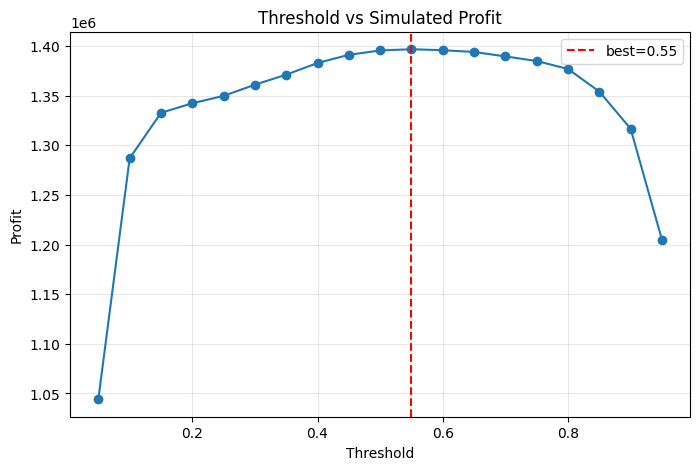

In [14]:

plt.figure(figsize=(8, 5))
plt.plot(business_df["threshold"], business_df["profit"], marker="o")
plt.axvline(best_profit_row["threshold"], color="red", linestyle="--", label=f"best={best_profit_row['threshold']:.2f}")
plt.title("Threshold vs Simulated Profit")
plt.xlabel("Threshold")
plt.ylabel("Profit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 12. Feature importance


In [15]:

# LightGBM importance
if hasattr(lgb_model, "feature_importances_"):
    fi_lgb = pd.DataFrame({
        "feature": X_train_tree.columns,
        "importance": lgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(fi_lgb.head(30))
    fi_lgb.to_csv(ARTIFACT_DIR / "lightgbm_feature_importance.csv", index=False)


,feature,importance
12,last_gap_days,885
10,total_amount_paid,701
19,days_since_reg,409
24,arpu,355
3,registered_via,241
22,txn_recency_ratio,216
0,city,193
21,days_since_last_txn,171
4,n_txns,169
5,cancel_rate,110


In [16]:

# XGBoost importance
if hasattr(xgb_model, "feature_importances_"):
    fi_xgb = pd.DataFrame({
        "feature": X_train_tree.columns,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(fi_xgb.head(30))
    fi_xgb.to_csv(ARTIFACT_DIR / "xgboost_feature_importance.csv", index=False)


,feature,importance
8,share_30d,0.375806
6,auto_renew_rate,0.165500
30,cancel_pressure,0.115162
29,subscription_stability,0.112785
10,total_amount_paid,0.037678
4,n_txns,0.036913
5,cancel_rate,0.032975
12,last_gap_days,0.024342
7,avg_plan_days,0.019518
21,days_since_last_txn,0.016746



## 13. Save artifacts


In [17]:

joblib.dump(logit_model, ARTIFACT_DIR / "logistic_model.joblib")
joblib.dump(lgb_model, ARTIFACT_DIR / "lightgbm_model.joblib")
joblib.dump(xgb_model, ARTIFACT_DIR / "xgboost_model.joblib")

pred_df = pd.DataFrame({
    "y_true": y_val.values,
    "logit_proba": logit_val_proba,
    "lgb_proba": lgb_val_proba,
    "xgb_proba": xgb_val_proba
})
pred_df.to_parquet(ARTIFACT_DIR / "validation_predictions.parquet", index=False)

with open(ARTIFACT_DIR / "best_threshold_by_f1.json", "w", encoding="utf-8") as f:
    json.dump(best_f1_row.to_dict(), f, ensure_ascii=False, indent=2)

with open(ARTIFACT_DIR / "best_threshold_by_profit.json", "w", encoding="utf-8") as f:
    json.dump(best_profit_row.to_dict(), f, ensure_ascii=False, indent=2)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())


Artifacts saved to: C:\Users\Admin\.vscode\powz\Project2\Artifacts



## 14. Next step after this notebook

Sau khi có baseline từ notebook này, bước tiếp theo nên là:

1. So sánh kết quả với benchmark / winning-solution intuition  
2. Chuyển từ random split sang **time-based validation**
3. Kiểm định nhóm feature:
   - subscription only
   - logs only
   - temporal only
   - full feature set
4. Tạo segmentation + decision layer + Power BI dashboard
